In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, cumulative_trapezoid, trapezoid
from scipy.interpolate import RegularGridInterpolator
from multiprocessing import Pool
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# ====================================================
# Loading CC data
# ====================================================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc  = df_cc["z_cc"].to_numpy(float)
H_obs = df_cc["H_cc"].to_numpy(float)
H_err = df_cc["H_cc_err"].to_numpy(float)

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,  H0_max  = 50.0, 90.0
Om0_min, Om0_max = 0.1,  0.6
lbd_min, lbd_max = 1.54, 10.0

# ST model index (fixed)
n = 1

# Scalaron mass scale
delta_s = 1e-7

# ====================================================
# Redshift / scale-factor / number of e-folds grids
# ====================================================

ai,    af    = 0.2,        1.0
zi,    zf    = 0.0,        4.0
ln_ai, ln_af = np.log(ai), np.log(af)

N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)  

In [4]:
# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for yH(t=lna) in ST f(R) gravity
# ====================================================

def yH_ST_ode(lna, y, H0, Om0, lbd):
    
    yH, YH = y
    a = np.exp(lna)
    
    ms  = H0**2 * Om0
    Rs  = 6.0 * H0**2 * (1.0 - Om0) / lbd
    M2  = Rs / delta_s
    
    R = 3.0 * ms * (YH + 4*yH + a**(-3))
    
    ratio = R / Rs
    ratio2 = ratio**2
    term_base = 1.0 + ratio2
    
    f_R = R + lbd * Rs * (term_base**(-n) - 1) + R**2 / (6 * M2)
    fR = 1.0 - 2.0 * n * lbd * ratio * term_base**(-n-1) + R / (3 * M2)
    fRR = -(2.0 * n * lbd / Rs) * term_base**(-n-1) * ( 1.0 - 2*(n + 1) * ratio2 * term_base**(-1) ) + 1.0 / (3 * M2)
    
    if fRR == 0.0 or not np.isfinite(fRR):
        raise ODEFailure(f"fRR singular at lna={lna:.4f}")
    
    yaux1 = yH + a**(-3)
    yaux2 = a**(-3)
    yaux3 = ((1 - fR) * yaux2) + ((R - f_R) / (3 * ms))
    
    J1 = 4.0 + (1.0 / yaux1) * ((1.0 - fR) / (6.0 * ms * fRR))
    J2 = (1.0 / yaux1) * ((2.0 - fR) / (3.0 * ms * fRR))
    J3 = -(3.0 * yaux2) - (yaux3 / yaux1) * (1.0 / (6.0 * ms * fRR))
    
    dYH = -J1 * YH - J2 * yH - J3
    return [YH, dYH]


# ====================================================
# ODE integration → H(lna)
# ====================================================

def H_ST_lna(lna_eval, H0, Om0, lbd):
    ms  = H0**2 * Om0
    yH0 = (1.0 - Om0) / Om0
    YH0 = 0.0
    y0  = [yH0, YH0]
    try:
        sol = solve_ivp(
            yH_ST_ode,
            (ln_ai, ln_af),
            y0,
            t_eval=lna_eval,
            method="LSODA",
            rtol=1e-6,
            atol=1e-8,
            args=(H0, Om0, lbd),
            dense_output=False
        )
    except Exception:
        return None
    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None
    a_eval = np.exp(lna_eval)
    yH_sol = sol.y[0]
    H_sol  = np.sqrt(ms * (yH_sol + a_eval**(-3)))
    return H_sol


# ====================================================
# H(z) via lna = - ln(1+z) conversion
# ====================================================

def H_ST_z(z_eval, H0, Om0, lbd):
    z_eval    = np.atleast_1d(np.asarray(z_eval, dtype=float))
    lna_eval  = - np.log(1.0 + z_eval)
    in_domain = (lna_eval >= ln_ai) & (lna_eval <= ln_af)
    if not np.any(in_domain):
        return None
    valid_idx   = np.where(in_domain)[0]
    lna_valid   = lna_eval[valid_idx]
    sort_idx    = np.argsort(lna_valid)
    lna_sorted  = lna_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(lna_sorted) > 1e-12))
    lna_unique  = lna_sorted[unique_mask]
    H_unique    = H_ST_lna(lna_unique, H0, Om0, lbd)
    if H_unique is None:
        return None
    if not np.all(unique_mask):
        H_at_sorted = np.interp(lna_sorted, lna_unique, H_unique)
    else:
        H_at_sorted = H_unique
    H_valid           = np.empty(len(lna_valid))
    H_valid[sort_idx] = H_at_sorted
    H_z               = np.full(len(z_eval), np.nan)
    H_z[valid_idx]    = H_valid
    return H_z

print("H_ST_z =", H_ST_z(z_cc, 70, 0.3, 8.54))

H_ST_z = [ 72.3113766   73.02629193  74.13467749  76.07709083  76.43922719
  77.25749885  77.29890018  80.310955    80.75936972  84.11840573
  85.49526466  86.48214611  86.50225289  87.73624562  89.03122629
  90.10148287  90.54386172  90.63481022  96.93400934 102.11159658
 106.47380188 106.47380188 108.45951407 109.69252706 114.67534192
 115.01397145 116.37639719 126.03993925 142.92751766 146.09827273
 151.17553101 156.6846805  165.10982461 184.45278877 204.36309062]


In [5]:
# # ====================================================
# # Worker function (module level — required for pickle)
# # ====================================================

# def _grid_worker_ST(args):
#     """
#     Computes H(z) for a single (H0, Om0, lbd) grid point.
#     The grid is always built in LINEAR lbd space.
#     Returns (i, j, k, H_values) or (i, j, k, None) on failure.
#     """
    
#     i, j, k, H0, Om0, lbd, z_pts = args
#     Hvals = H_ST_z(z_pts, H0, Om0, lbd)
#     if Hvals is not None and np.all(np.isfinite(Hvals)):
#         return (i, j, k, Hvals)
#     else:
#         return (i, j, k, None)


# # ====================================================
# # Parallel grid builder
# # ====================================================

# def build_H_grid_parallel_ST(H0_pts, Om0_pts, lbd_pts, z_pts,
#                               n_cores=None, verbose=True):
#     nH    = len(H0_pts)
#     nOm   = len(Om0_pts)
#     nlbd  = len(lbd_pts)
#     nz    = len(z_pts)
#     total = nH * nOm * nlbd
#     n_cores = n_cores or os.cpu_count()
#     tasks = [
#         (i, j, k, H0, Om0, lbd, z_pts)
#         for i, H0  in enumerate(H0_pts)
#         for j, Om0 in enumerate(Om0_pts)
#         for k, lbd in enumerate(lbd_pts)
#     ]
#     H_array   = np.full((nH, nOm, nlbd, nz), np.nan)
#     nan_count = 0
#     if verbose:
#         print(f"  ST model index    : n = {n}")
#         print(f"  Total grid points : {total} ({nH}×{nOm}×{nlbd})")
#         print(f"  Workers           : {n_cores}")
#         print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
#         print("  " + "-"*55)
#     t0       = time.time()
#     count    = 0
#     last_pct = -1
#     chunksize = max(1, total // (n_cores * 20))
#     with Pool(processes=n_cores) as pool:
#         for result in pool.imap_unordered(_grid_worker_ST, tasks,
#                                           chunksize=chunksize):
#             i, j, k, Hvals = result
#             if Hvals is not None:
#                 H_array[i, j, k, :] = Hvals
#             else:
#                 nan_count += 1
#             count   += 1
#             elapsed  = time.time() - t0
#             pct      = int(count / total * 100)
#             if verbose and (pct >= last_pct + 10 or count == total):
#                 eta  = (elapsed / count) * (total - count) if count < total else 0.0
#                 rate = count / elapsed if elapsed > 0 else 0.0
#                 print(f"  {pct:>4}%  {count:>8}/{total}  "
#                       f"{elapsed:>7.1f}s  "
#                       f"ETA {eta:>6.1f}s  "
#                       f"{rate:>8.1f} pts/s")
#                 last_pct = pct
#     nan_frac = nan_count / total
#     if nan_frac > 0:
#         print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
#               f"check prior bounds or ODE stability.")
#     else:
#         print(f"\n  ✓  Grid complete with no NaN points.")
#     total_time = time.time() - t0
#     print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")
#     return H_array


# # ====================================================
# # Interpolation error validation
# # ====================================================

# def validate_interpolation_error_ST(H_interp_4D, H0_pts, Om0_pts, lbd_pts, z_pts,
#                                     n_test=300, tol_percent=0.5):
#     """
#     Validates the interpolator against direct ODE solutions at
#     n_test random interior points (sampled in LINEAR lbd space).
#     """
    
#     rng_v  = np.random.default_rng(0)
#     errors = []
#     for _ in range(n_test):
#         H0_t    = rng_v.uniform(H0_pts[1],   H0_pts[-2])
#         Om0_t   = rng_v.uniform(Om0_pts[1],  Om0_pts[-2])
#         lbd_t   = rng_v.uniform(lbd_pts[1],  lbd_pts[-2])
#         H_true  = H_ST_z(z_pts, H0_t, Om0_t, lbd_t)
#         if H_true is None or not np.all(np.isfinite(H_true)):
#             continue
#         pts      = np.column_stack([np.full(len(z_pts), H0_t),
#                                     np.full(len(z_pts), Om0_t),
#                                     np.full(len(z_pts), lbd_t),
#                                     z_pts])
#         H_interp = H_interp_4D(pts)
#         rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
#         errors.append(np.max(rel_err))
#     errors = np.array(errors)
#     print(f"\n  Interpolation validation ({n_test} random interior points):")
#     print(f"  Max error    : {errors.max():.4f}%")
#     print(f"  Median error : {np.median(errors):.4f}%")
#     print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
#     if errors.max() < tol_percent:
#         print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
#               f"Ready for MCMC.")
#     else:
#         print(f"  ✗  Max error exceeds {tol_percent}%! "
#               f"Increase grid resolution (n_H0, n_Om0, n_lbd).")
#     return errors


# # ====================================================
# # 4D interpolation grid parameters
# # ====================================================

# n_H0  = 30
# n_Om0 = 30
# n_lbd = 30

# H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
# Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
# lbd_grid_pts = np.linspace(lbd_min, lbd_max, n_lbd)


# # ====================================================
# # Build grid (parallel)
# # ====================================================

# print(f"\n=== Building 4D interpolation grid (parallel) | ST n={n} ===")
# H_array = build_H_grid_parallel_ST(
#     H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid,
#     n_cores=os.cpu_count()
# )


# # ====================================================
# # Save grid for reuse
# # ====================================================

# np.save(f"H_array_ST_n{n}_{n_lbd}_grid.npy", H_array)


# # ====================================================
# # Build interpolator
# # ====================================================

# H_interp_4D = RegularGridInterpolator(
#     (H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid),
#     H_array,
#     method="linear",
#     bounds_error=False,
#     fill_value=np.nan
# )


# # ====================================================
# # Validate interpolator
# # ====================================================

# print(f"\n=== Validating interpolator | ST n={n} ===")
# errors = validate_interpolation_error_ST(
#     H_interp_4D, H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid
# )

In [6]:
# =====================================================
# Load and validation of the grid
# =====================================================

# 4D interpolation grid parameters
n_H0  = 30
n_Om0 = 30
n_lbd = 30

H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
lbd_grid_pts = np.linspace(lbd_min, lbd_max, n_lbd)

# Load grid from file
H_array_path = "/home/brunowesley/projetos/MCMC-cosmo/Codes/MG-based/Starobinsky/CC/H_array_ST_n1_30_grid.npy"
H_array = np.load(H_array_path)

# Build interpolator
H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

# Interpolation error validation
def validate_interpolation_error_ST(H_interp_4D, H0_pts, Om0_pts, lbd_pts, z_pts,
                                    n_test=300, tol_percent=0.5):
    rng_v  = np.random.default_rng(0)
    errors = []
    for _ in range(n_test):
        H0_t   = rng_v.uniform(H0_pts[1],  H0_pts[-2])
        Om0_t  = rng_v.uniform(Om0_pts[1], Om0_pts[-2])
        lbd_t  = rng_v.uniform(lbd_pts[1], lbd_pts[-2])
        H_true = H_ST_z(z_pts, H0_t, Om0_t, lbd_t)
        if H_true is None or not np.all(np.isfinite(H_true)):
            continue
        pts      = np.column_stack([np.full(len(z_pts), H0_t),
                                    np.full(len(z_pts), Om0_t),
                                    np.full(len(z_pts), lbd_t),
                                    z_pts])
        H_interp = H_interp_4D(pts)
        rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
        errors.append(np.max(rel_err))
    errors = np.array(errors)
    print(f"\n  Interpolation validation ({n_test} random interior points):")
    print(f"  Max error    : {errors.max():.4f}%")
    print(f"  Median error : {np.median(errors):.4f}%")
    print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
    if errors.max() < tol_percent:
        print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
              f"Ready for MCMC.")
    else:
        print(f"  ✗  Max error exceeds {tol_percent}%! "
              f"Increase grid resolution (n_H0, n_Om0, n_lbd).")
    return errors

# Validate
print(f"\n=== Validating interpolator | ST n={n} ===")
errors = validate_interpolation_error_ST(
    H_interp_4D, H0_grid_pts, Om0_grid_pts, lbd_grid_pts, z_grid
)


=== Validating interpolator | ST n=1 ===

  Interpolation validation (300 random interior points):
  Max error    : 0.0503%
  Median error : 0.0055%
  95th pct     : 0.0274%
  ✓  Interpolator approved (max error < 0.5%). Ready for MCMC.


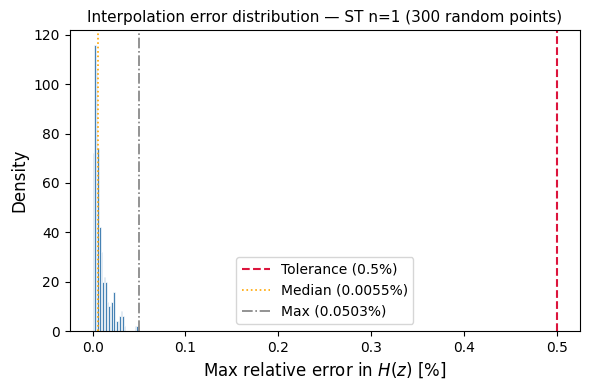

In [8]:
# ====================================================
# Interpolation error distribution plot
# ====================================================

def plot_interpolation_errors(errors, tol_percent=0.5, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(errors, bins=30, color="steelblue", edgecolor="white",
            linewidth=0.5, density=True)
    ax.axvline(tol_percent, color="crimson", lw=1.5, ls="--",
               label=f"Tolerance ({tol_percent}%)")
    ax.axvline(np.median(errors), color="orange", lw=1.2, ls=":",
               label=f"Median ({np.median(errors):.4f}%)")
    ax.axvline(errors.max(), color="gray", lw=1.2, ls="-.",
               label=f"Max ({errors.max():.4f}%)")
    ax.set_xlabel("Max relative error in $H(z)$ [%]", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(f"Interpolation error distribution — ST n={n} (300 random points)",
                 fontsize=11)
    ax.legend(fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_interpolation_errors(errors, save_path=f"interp_error_ST_n{n}_cc.png")

In [9]:
# ====================================================
# H(z) via interpolator
# ====================================================

def H_ST_interp(z_eval, H0, Om0, lbd):
    """Query interpolator with physical (linear) lbd."""
    
    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), lbd),
        z_eval
    ])
    return H_interp_4D(pts)


# ==========================
# Quick test
# ==========================

print("H_ST_interp(z_cc) =", 
       H_ST_interp(z_cc, 70, 0.3, 3.0))

H_ST_interp(z_cc) = [ 72.46205815  73.22965533  74.41267551  76.47107176  76.85267756
  77.71197378  77.75516719  80.8956109   81.35989687  84.82070349
  86.23033059  87.23740324  87.25782683  88.51516783  89.83119771
  90.91608449  91.36435275  91.45616673  97.80629669 102.99421922
 107.35030403 107.35030403 109.33051196 110.55872515 115.51784073
 115.85439246 117.20900883 126.8067553  143.56132256 146.70754769
 151.7461999  157.21453181 165.58106595 184.80939321 204.62513693]


In [10]:
# ====================================================
# Observable error analysis
# ====================================================

def analyze_H_error_cc(H0, Om0, lbd):
    H_true   = H_ST_z(z_cc, H0, Om0, lbd)
    H_interp = H_ST_interp(z_cc, H0, Om0, lbd)
    if H_true is None or H_interp is None:
        print("Model evaluation failed.")
        return None
    abs_error          = np.abs(H_interp - H_true)
    rel_error          = abs_error / np.abs(H_true)
    pct_error          = 100.0 * rel_error
    chi_ratio          = abs_error / H_err
    chi2_per_point_max = np.max(chi_ratio**2)
    chi2_total_upper   = np.sum(chi_ratio**2)
    results = {
        "Metric": [
            "Max absolute error [km/s/Mpc]",
            "Median absolute error [km/s/Mpc]",
            "Max relative error",
            "Median relative error",
            "Max percent error [%]",
            "Median percent error [%]"
        ],
        "Value": [
            np.max(abs_error),
            np.median(abs_error),
            np.max(rel_error),
            np.median(rel_error),
            np.max(pct_error),
            np.median(pct_error)
        ]
    }
    df_results = pd.DataFrame(results)
    print(f"\n=== Observable Error Summary (ST n={n} | H using z_cc) ===\n")
    print(df_results.to_string(index=False))
    print("\n=== chi^2 Impact Assessment ===\n")
    print(f"Max |ΔH|/σ                     : {np.max(chi_ratio):.6e}")
    print(f"Max contribution to chi^2 (1pt): {chi2_per_point_max:.6e}")
    print(f"Total chi^2 shift (upper bound): {chi2_total_upper:.6e}")
    return df_results

_ = analyze_H_error_cc(H0=70.0, Om0=0.3, lbd=3.0)


=== Observable Error Summary (ST n=1 | H using z_cc) ===

                          Metric    Value
   Max absolute error [km/s/Mpc] 0.013990
Median absolute error [km/s/Mpc] 0.002556
              Max relative error 0.000072
           Median relative error 0.000028
           Max percent error [%] 0.007170
        Median percent error [%] 0.002790

=== chi^2 Impact Assessment ===

Max |ΔH|/σ                     : 8.480349e-04
Max contribution to chi^2 (1pt): 7.191632e-07
Total chi^2 shift (upper bound): 2.579768e-06


In [11]:
# ====================================================
# CC likelihood
# ====================================================

def lnprior_cc(theta_cc):
    H0, Om0, lbd = theta_cc
    if not (H0_min  <= H0  <= H0_max):  return -np.inf
    if not (Om0_min <= Om0 <= Om0_max): return -np.inf
    if not (lbd_min <= lbd <= lbd_max): return -np.inf
    return 0.0

def lnlike_cc(theta_cc, z_cc, H_obs, H_err):
    H0, Om0, lbd = theta_cc
    H_model = H_ST_interp(z_cc, H0, Om0, lbd)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    return -0.5 * np.sum(((H_obs - H_model) / H_err)**2)

def lnprob_cc(theta_cc, z_cc, H_obs, H_err):
    lp = lnprior_cc(theta_cc)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc(theta_cc, z_cc, H_obs, H_err)


# ====================================================
# Quick test
# ====================================================

theta_cc_test = [70.0, 0.3, 10.0]
print("CC log-posterior =",
       lnprob_cc(theta_cc_test, z_cc, H_obs, H_err))

CC log-posterior = -7.584001835133457


In [12]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 3
nwalkers = 30
nsteps   = 30000

# Initial position
theta0 = np.array([70.0, 0.3,  5.0])  
scales = np.array([ 2.0, 0.02, 1.0])    

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))
for i in range(nwalkers):
    while not np.isfinite(lnprior_cc(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (ST n={n} | CC | Uniform prior on lbd) ===")
t_mcmc = time.time()
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc,
    args=(z_cc, H_obs, H_err)
)
sampler.run_mcmc(p0, nsteps, progress=True)
print(f"MCMC completed in {(time.time() - t_mcmc)/60:.2f} min")


=== Running MCMC (ST n=1 | CC | Uniform prior on lbd) ===


100%|██████████| 30000/30000 [01:19<00:00, 377.61it/s]

MCMC completed in 1.32 min


In [13]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")
chain        = sampler.get_chain()
nsteps_total = chain.shape[0]
acc_frac     = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn  = int(3 * tau_max)
nthin  = max(1, int(tau_max / 2))
n_post = nsteps_total - nburn
N_eff  = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.596
Acceptance status: ACCEPTABLE

Max autocorrelation time τ_max = 54.83
Chain length / τ_max           = 547.1
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 164 steps (0.5%)
Thin (τ_max/2)                 = 27
Minimum N_eff                  = 16324
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [14]:
# ====================================================
# Chain extraction
# ====================================================

# flat_samples = sampler.get_chain(discard=nburn, thin=nthin, flat=True)    # Apply thin
flat_samples = sampler.get_chain(discard=nburn, flat=True)                  # No thin

# Save
fname       = f"flat_samples_HS_n{n}_cc.npy"
np.save(fname,       flat_samples)

print(f"\nFinal posterior samples : {len(flat_samples)}")
print(f"Burn-in used            : {nburn} steps")
print(f"Saved to                : {fname}")


Final posterior samples : 895080
Burn-in used            : 164 steps
Saved to                : flat_samples_HS_n1_cc.npy


Removed no burn in


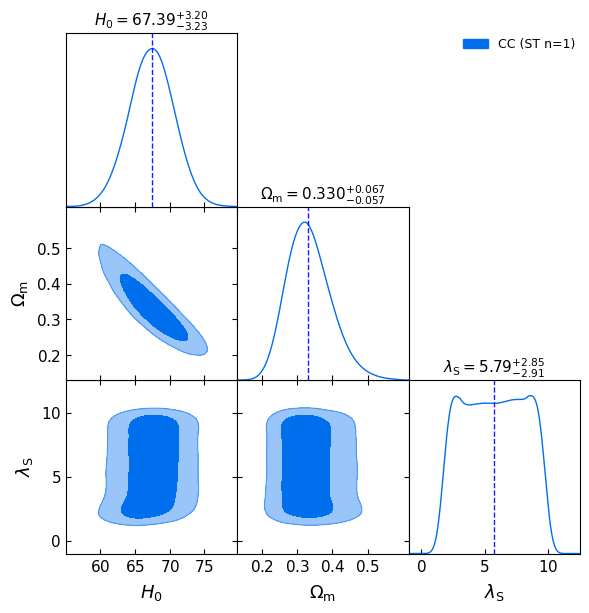

In [19]:
# ====================================================
# Corner plot (GetDist) — mu_HS directly
# ====================================================

param_names  = ["H0", "Om0", "lbd"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\lambda_{\rm S}"]
fmt_map      = {"H0": ".2f", "Om0": ".3f", "lbd": ".2f"}

samples_gd = MCSamples(
    samples=flat_samples,          
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=[f"CC (ST n={n})"],
                title_limit=0)

# Add titles with median ± 68% CL
for i, name in enumerate(param_names):
    samp   = flat_samples[:, i]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax      = g.subplots[i, i]
    line    = ax.get_lines()[0]
    line.set_linewidth(1.0)
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = f"Corner_ST_n{n}_cc.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# ====================================================
# Marginalized statistics
# ====================================================

print("\n" + "="*60)
print(f"{'Final Inference Results (ST n='+str(n)+' | CC data)':^60}")
print("="*60)

for name, idx, fmt in [("H0", 0, ".2f"), ("Om0", 1, ".3f"), ("lbd", 2, ".2f")]:
    samp    = flat_samples[:, idx]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    lower95 = np.percentile(samp, 2.5)
    upper95 = np.percentile(samp, 97.5)
    ep68 = upper68 - median;  em68 = median - lower68
    ep95 = upper95 - median;  em95 = median - lower95
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:.{fmt[1:]}}")

print("\n" + "="*60)


         Final Inference Results (ST n=1 | CC data)         

  H0:
    67.39 +3.20 -3.23  (68% CL)
    67.39 +6.22 -6.40

  Om0:
    0.330 +0.067 -0.057  (68% CL)
    0.330 +0.143 -0.105

  lbd:
    5.79 +2.85 -2.91  (68% CL)
    5.79 +4.00 -4.04



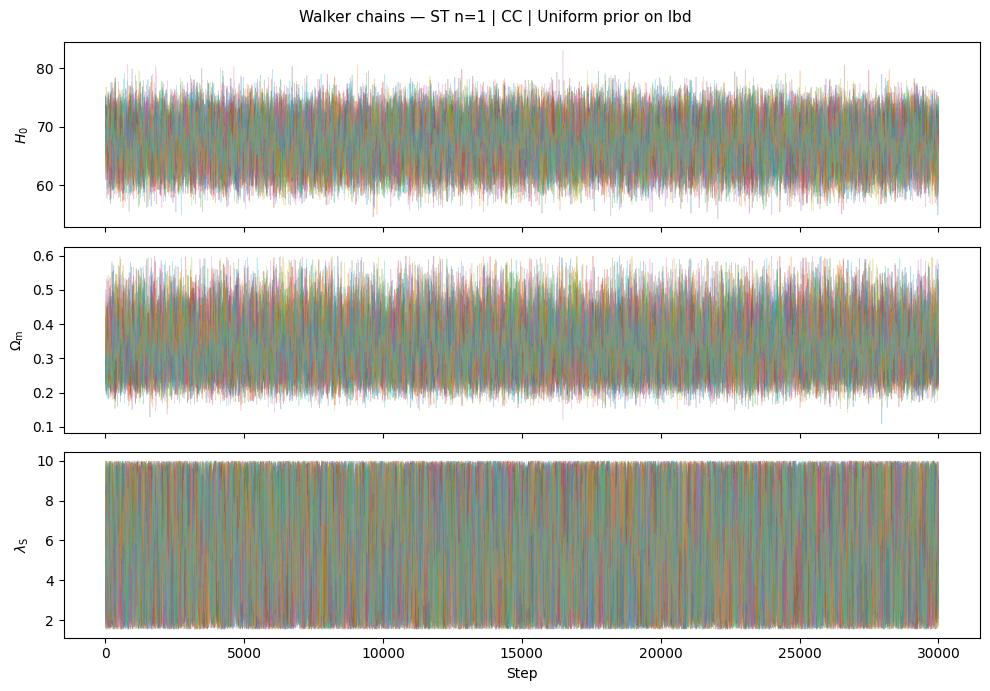

In [18]:
# ====================================================
# Walker chains
# ====================================================

chain_plot   = sampler.get_chain().copy()
chain_labels = [r"$H_0$", r"$\Omega_{\rm m}$", r"$\lambda_{\rm S}$"]

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
for i, label in enumerate(chain_labels):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.suptitle(f"Walker chains — ST n={n} | CC | Uniform prior on lbd",
             fontsize=11)

plt.tight_layout()
plt.show()